In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [41]:
df = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_gene_protein.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df = df.loc[:, ~df.columns.str.contains('Norm')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df = df.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T
df1 = df.drop(['ATXN7', 'ATXN7', 'ABCF2', 'ABCF2', 'GGT1', 'GGT1', 'PINX1', 'PINX1',
       'POLR2J3', 'POLR2J3'],axis = 1) #columnas duplicadas
df2 = df[['ATXN7', 'ABCF2', 'GGT1', 'PINX1',  'POLR2J3']]
##Cambiamos los nombres de las columnas duplicadas
cols = ['ATXN7', 'ATXN7', 'ABCF2', 'ABCF2', 'GGT1', 'GGT1', 'PINX1', 'PINX1','POLR2J3', 'POLR2J3']
col_counts = defaultdict(int)
new_cols = []

for col in cols:
    if col_counts[col] == 0:
        new_cols.append(f"{col}_a")
    else:
        new_cols.append(f"{col}_b")
    col_counts[col] += 1
df2.columns = new_cols
df_raw = pd.concat([df1,df2], axis=1)

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

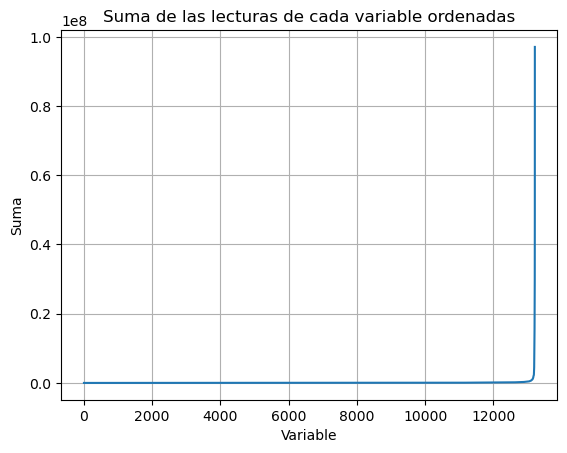

In [42]:

plt.plot(df_raw.sum().sort_values().to_list())
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

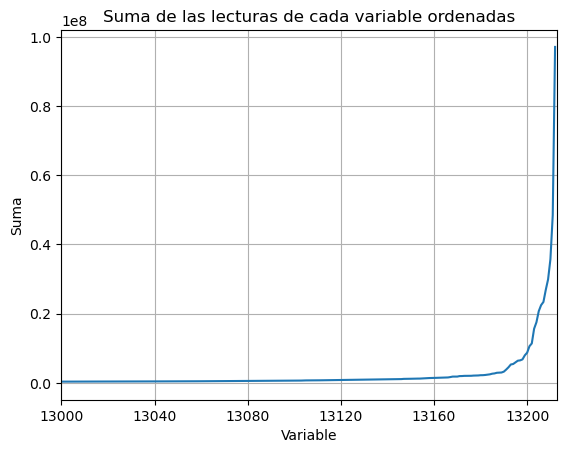

In [43]:
plt.xticks(np.arange(13000, 13213 , 40))
plt.plot(df_raw.sum().sort_values().to_list())
plt.xlim(13000, 13213)
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

In [44]:
x_objetivo = 13000

suma_lecturas = df_raw.sum().sort_values()
suma_lecturas_list = suma_lecturas.to_list()
indice_mas_cercano = np.abs(suma_lecturas.reset_index(drop = True).index - x_objetivo).argmin()
valor_y_correspondiente = suma_lecturas.iloc[indice_mas_cercano]

print(f"El valor de y correspondiente a x={x_objetivo} es: {valor_y_correspondiente}")

El valor de y correspondiente a x=13000 es: 373526


In [45]:
suma_min = valor_y_correspondiente
filtered = df_raw.sum().sort_values()
cols_interes = filtered[filtered>suma_min].index.to_list()
df_raw_lecAltas1 = df_raw[cols_interes]
len(df_raw_lecAltas1.columns)

212

### MAgnitud mínima

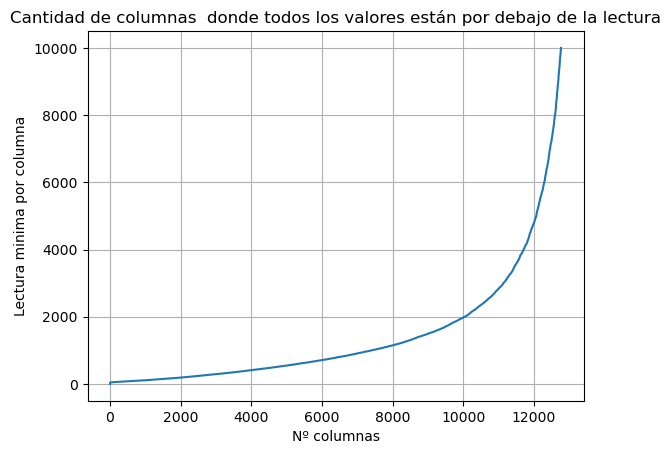

In [52]:
lista_mediaCercACero = []
lecturas_mins = range(0,10000)
for lectMin in lecturas_mins:
    #for frec in np.arange(0,1,0.1):
    mediaCercACero = (df_raw < lectMin).sum() #vemos cuántos valores de cada columna están por debajo de ese umbral
    mediaCercACero = mediaCercACero[mediaCercACero == len(df_raw)] #Filtramos las columnas en donde todos los valores están por debajo de ese umbral
    lista_mediaCercACero.append(len(mediaCercACero))
#plt.xticks(np.arange(0,20,1))
plt.plot(lista_mediaCercACero, lecturas_mins)
plt.xlabel('Nº columnas')
plt.ylabel('Lectura minima por columna')
plt.title('Cantidad de columnas  donde todos los valores están por debajo de la lectura') 
plt.grid(True)
plt.show()

In [62]:
ncol = 12000
indice_mas_cercano = np.abs(np.array(lista_mediaCercACero) - ncol).argmin()
lectura_correspondiente = lecturas_mins[indice_mas_cercano] 
print(f"El valor de lectura correspondiente a x={ncol} es aproximadamente: {lectura_correspondiente}")

El valor de lectura correspondiente a x=12000 es aproximadamente: 4773


In [63]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

1213

In [64]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

1213

In [65]:
colsLectAlta = list(set(df_raw_lecAltas1.columns.to_list() + df_raw_lecAltas2.columns.to_list()))
len(colsLectAlta)
print(len(df_raw.columns),'->',len(colsLectAlta))

13213 -> 1213


### Varianzas bajas

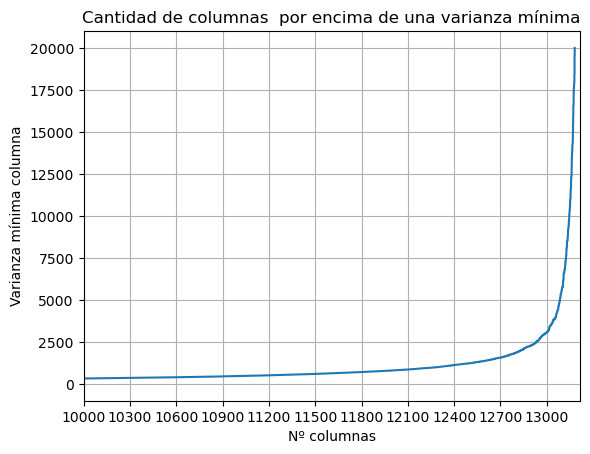

In [75]:
lista_vars = []
vars_mins = range(0,20000)
df_vars = df_raw.std()
for varMin in vars_mins:
    nVarsStd = len(df_vars[df_vars<varMin])
    lista_vars.append(nVarsStd)

plt.xticks(np.arange(10000, 13213,300))
plt.plot(lista_vars, vars_mins)
plt.xlim(10000, 13213)
plt.xlabel('Nº columnas')
plt.ylabel('Varianza mínima columna')
plt.title('Cantidad de columnas  por encima de una varianza mínima') 
plt.grid(True)
plt.show()

In [76]:
lista_vars_array = np.array(lista_vars)
vars_mins_array = np.array(vars_mins)
x_objetivo = 12800
indice_mas_cercano = np.abs(lista_vars_array - x_objetivo).argmin()
varianza_minima_correspondiente = vars_mins_array[indice_mas_cercano]

print(f"La varianza mínima correspondiente a x={x_objetivo} columnas es: {varianza_minima_correspondiente}")

La varianza mínima correspondiente a x=12800 columnas es: 1854


In [77]:
colsVarAlta = df_vars[df_vars>varianza_minima_correspondiente].index.to_list()
print(len(df_raw.columns),'->',len(colsVarAlta))


13213 -> 413


In [78]:
colsSeleccion = list(set(colsLectAlta + colsVarAlta))
df_raw_new = df_raw[colsSeleccion]
len(colsSeleccion)

1213

### Renormalizar

In [79]:
df_raw_new.to_csv('df_raw_Proteines_Normalizar.csv',index = False)

In [82]:
df_norm_TMM = pd.read_csv('cpm_tmmProteines.csv',index_col = 0)

In [104]:
df_norm_TMM.index = df_raw_new.index

### Tests

In [105]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [106]:
df_norm_seleccion = df_norm_TMM
df1_ct = df_norm_seleccion.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

print(len(variables),'→',len(variablesIncluir))

1213 → 78


### Correlaciones

In [122]:
df1 = df_norm_TMM[variablesIncluir]

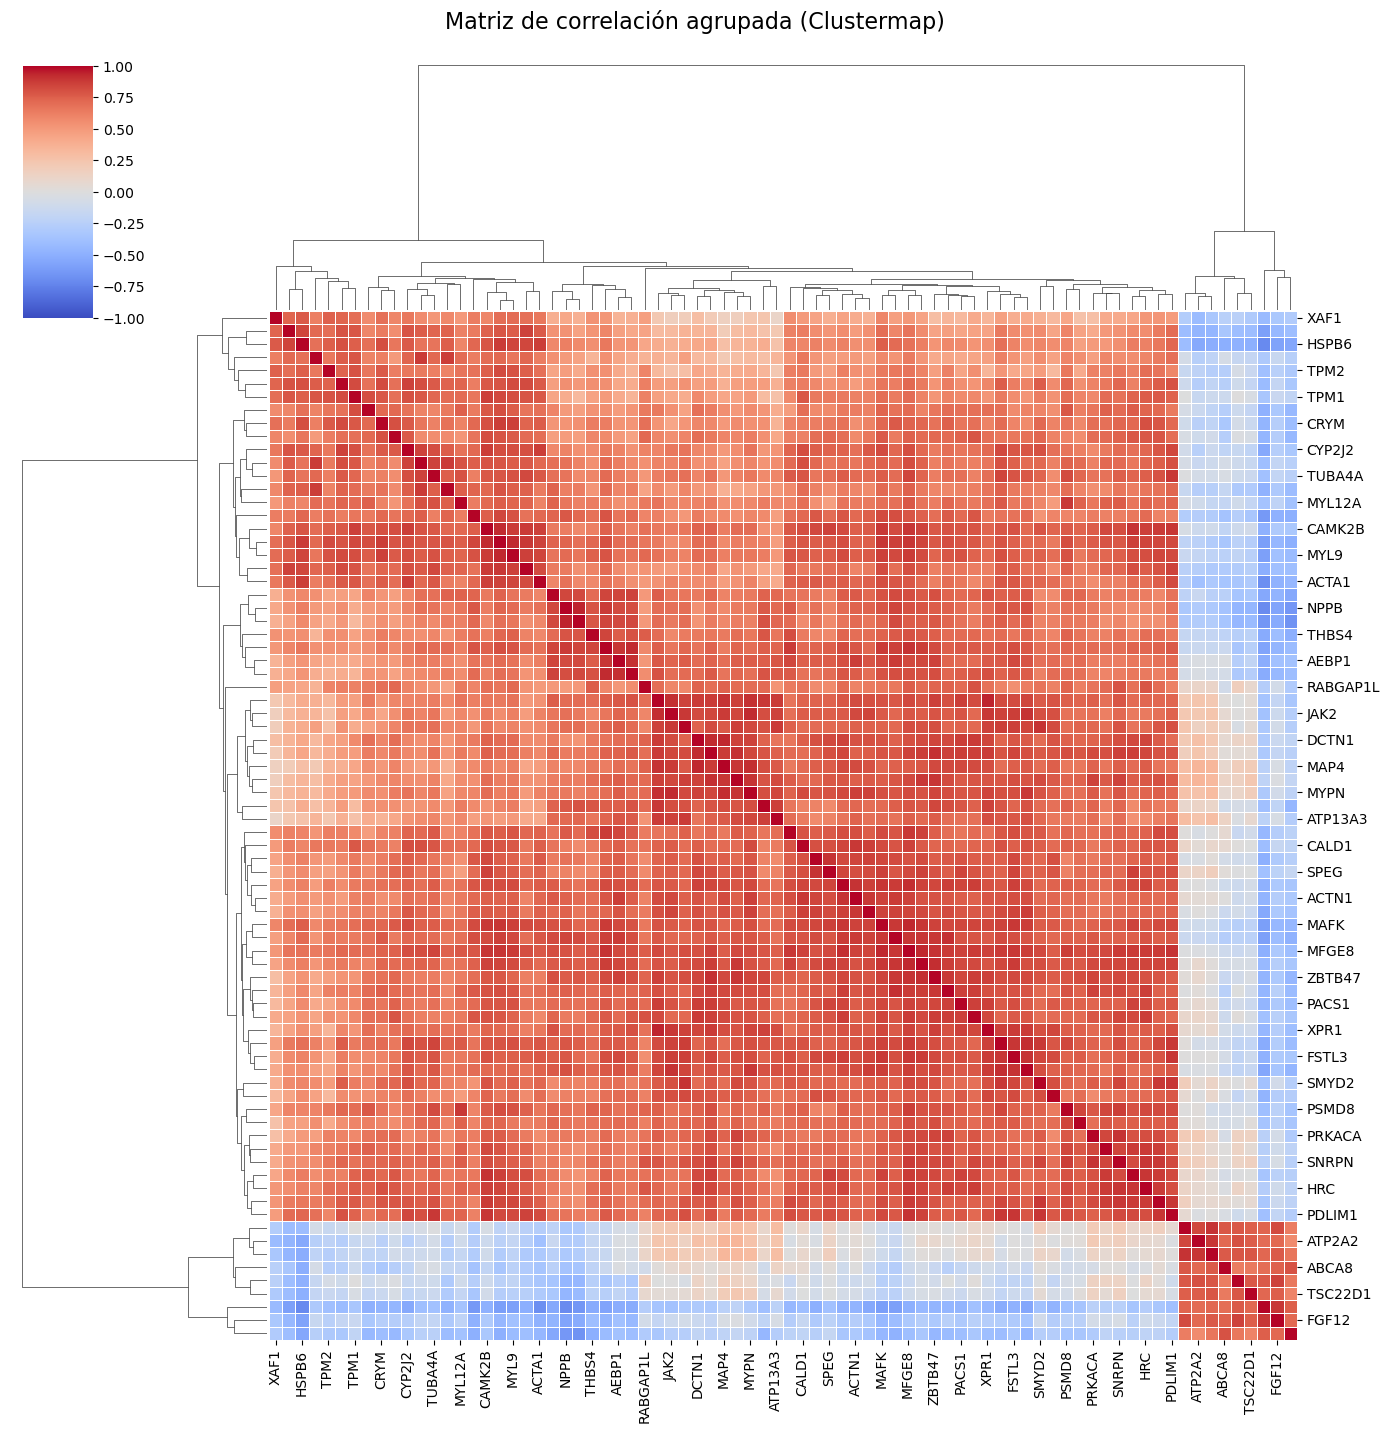

In [124]:
import seaborn as sns

corr = df1.corr(method='spearman')
cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7})
cluster.fig.suptitle('Matriz de correlación agrupada (Clustermap)', y=1.02, fontsize=16)
cluster.fig.savefig("graphics/clustermap_correlacionProteinas.png", bbox_inches='tight', dpi=300)
plt.show()

In [92]:
df_list = []
threshold = 0.8
correlaciones_vars = df1.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df1.columns)        
df1 = df1.drop(columns=columns_to_drop)   
print(nvarsAntes,'variables →',len(df1.columns),'variables')

78 variables → 10 variables


Mirar las 68 variables que desaparecen
Mirar cuáles tienen relacion con RNA's no codificantes
Ver por grupos de correlacion qué variable elegir en base a criterios
Clustering usando corr medida distancia => usar más cercano al centroide como representativo
Usar otras tecnicas de cluster (uno estandar) correlacion de Spearman como medida de distancia. Mirar un par de algoritmos 

### Árbol de clasificación

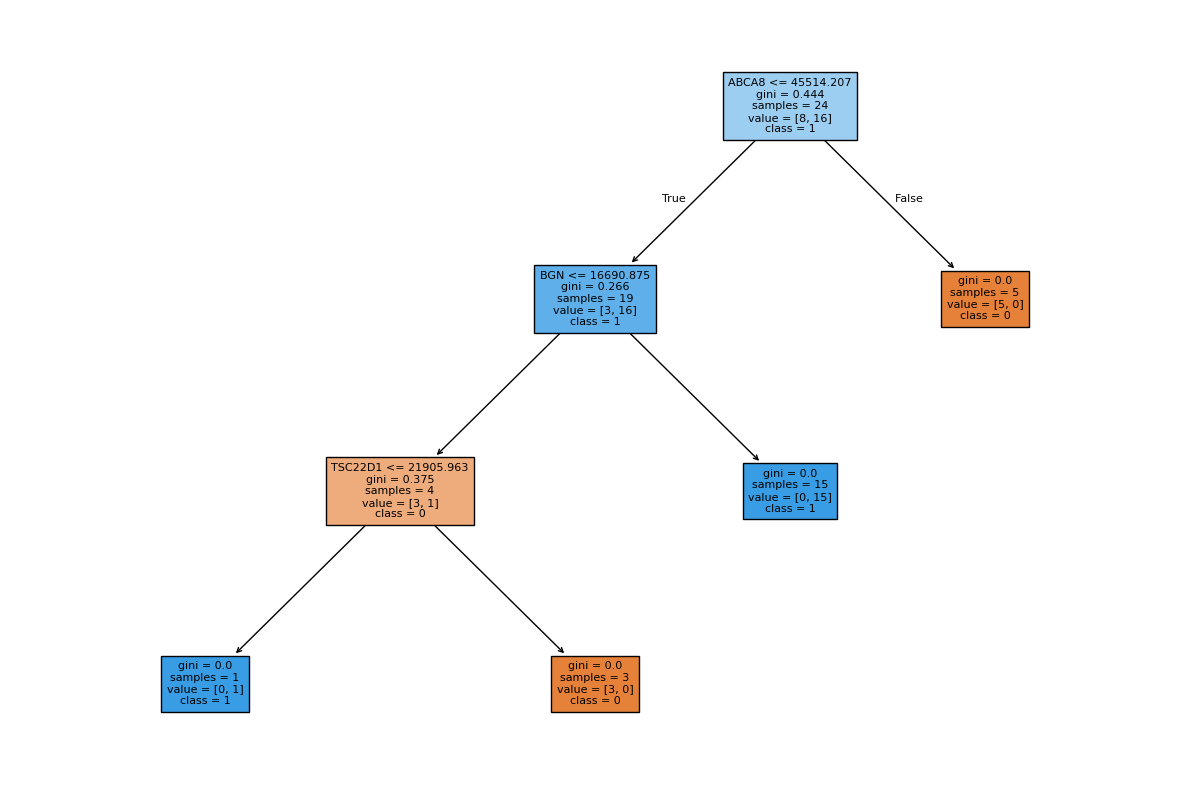

In [93]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

df2 = df1.copy().reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

X = df2.drop(columns=["Grupo_Tratamiento"])  
y = df2["Grupo_Tratamiento"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Evaluar
accuracy = clf.score(X_test, y_test)

plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=[str(c) for c in clf.classes_],
    fontsize=8  # Tamaño de fuente más pequeño
)
plt.tight_layout() 
plt.show()

### Random Forests

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score,cross_val_predict, train_test_split
from sklearn.metrics  import roc_curve, auc, accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


df2 = df1.copy().reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-pa

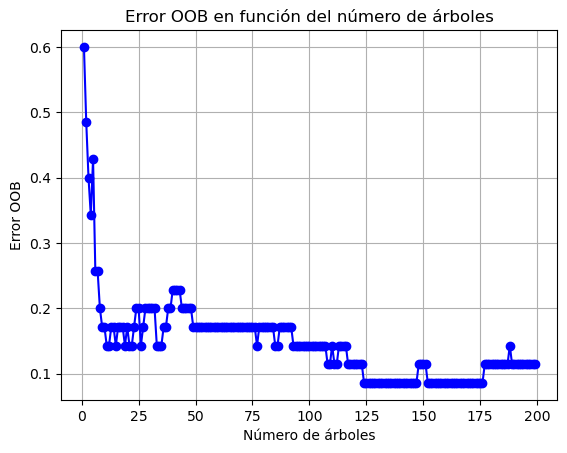

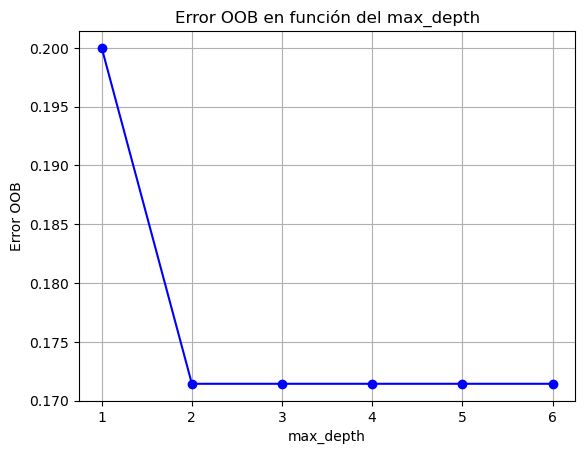

In [97]:
X = df2.drop(columns=["Grupo_Tratamiento"])  
y = df2["Grupo_Tratamiento"]
estimadores = range(1, 200, 1)
oob_errors = []

for n_estimators in estimadores:  
    rf = RandomForestClassifier(n_estimators=n_estimators, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(estimadores, oob_errors, marker='o', color='b')
plt.xlabel('Número de árboles')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del número de árboles')
plt.grid(True)
plt.show()

oob_errors = []
profundidades = range(1, 7)
for max_depth in profundidades:  
    rf = RandomForestClassifier(n_estimators=300, max_depth=max_depth, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(profundidades, oob_errors, marker='o', color='b')
plt.xlabel('max_depth')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del max_depth')
plt.grid(True)
plt.show()

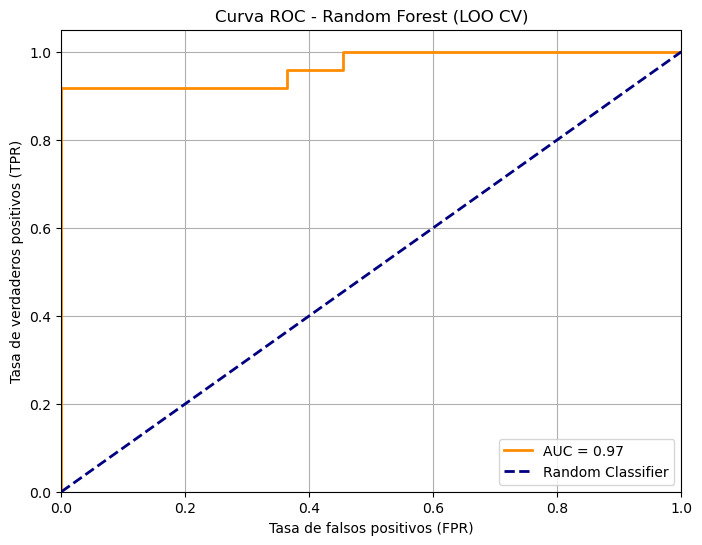

Precisión media en entrenamiento: 1.0
Precisión media en test: 0.8571428571428571
AUC de la curva ROC: 0.9659090909090908
Tasa de verdaderos negativos (TNR - especificidad): 0.7272727272727273
Tasa de falsos negativos (FNR): 0.08333333333333333
Tasa de verdaderos  positivos (TPR): 0.9166666666666666
Tasa de falsos positivos (FPR): 0.2727272727272727


In [111]:
n_estimators = 300
max_depth = 3

X = df2.drop(columns=["Grupo_Tratamiento"])  
y = df2["Grupo_Tratamiento"]

# Inicializar LOO
loo = LeaveOneOut()

# Acumuladores
accuracies_train = []
accuracies_test = []
y_true = []
y_pred_proba = []
y_pred_class = []
modelos = []
importancias = []
# Loop LOO
for train_index, test_index in loo.split(X):
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    
    rf.fit(X_train, y_train)

    # Predicciones
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    # Guardar resultados
    accuracies_train.append(accuracy_score(y_train, y_train_pred))
    accuracies_test.append(accuracy_score(y_test, y_test_pred))
    y_true.append(y_test.values[0])
    y_pred_proba.append(y_test_proba[0])
    y_pred_class.append(y_test_pred[0])
    importances = rf.feature_importances_
    feature_names = X.columns
    feat_importances = pd.DataFrame(importances, index=feature_names).T
    importancias.append(feat_importances)
    modelos.append(rf)
importancias = pd.concat(importancias)
# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_true, y_pred_class)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest (LOO CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
print("Precisión media en entrenamiento:", np.mean(accuracies_train))
print("Precisión media en test:", np.mean(accuracies_test))
print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)

In [112]:
importancias.mean().sort_values(ascending = False)

BGN        0.186069
ABCA8      0.181616
TSC22D1    0.128126
TNNT1      0.107138
MYL12A     0.105659
XAF1       0.086876
PTDSS1     0.075304
TPM2       0.071396
TRDN       0.031487
DCTN1      0.026327
dtype: float64

In [100]:
df2.corr()['Grupo_Tratamiento']

BGN                  0.546093
PTDSS1              -0.531092
DCTN1                0.432138
TPM2                 0.559503
TRDN                 0.432072
TNNT1                0.535075
ABCA8               -0.642890
MYL12A               0.530080
XAF1                 0.460562
TSC22D1             -0.592176
Grupo_Tratamiento    1.000000
Name: Grupo_Tratamiento, dtype: float64

### Logística

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [113]:
def discretizar_variables(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)

    return data_encoded

df3 = discretizar_variables(df1, 3)
df3 = pd.concat([df3,df2['Grupo_Tratamiento']], axis = 1)

Exactitud: 0.86
AUC: 1.00


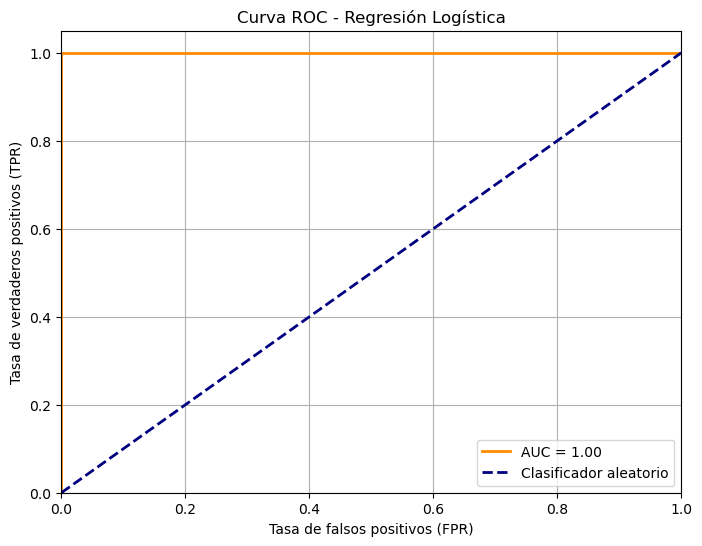

Coeficientes del modelo:


,Característica,Coeficiente
26,NPPA_2,0.780330
38,TP53INP2_2,0.085865
41,TPM2_2,0.055784
56,PKIG_2,0.284362
112,HSPB6_1,0.297932
116,CRYM_2,0.220492
120,C3_0,0.893820
136,FSTL3_1,0.123180
140,MCAM_2,0.568404
141,ATP2A2_0,0.667313


In [121]:
X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(penalty='l1', solver='liblinear')

# Entrenar el modelo
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1] 

accuracy = accuracy_score(y_test, y_pred)
print(f'Exactitud: {accuracy:.2f}')



fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
print(f'AUC: {roc_auc:.2f}')

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


coefficients = pd.DataFrame({
    'Característica': X.columns,
    'Coeficiente': log_reg.coef_[0]
})
print("Coeficientes del modelo:")
coefficients[coefficients['Coeficiente'] != 0]